# CommittedAgent Beta=3 Lambda Fit and Equal-to-Both Comparison

This notebook organizes the three recent analyses:

1. Trial-level commitment fit for `CommittedAgent` with `beta = 3.0`, plotting lambda from `0` to `0.5` with two lines: overall average and `equal_to_both`.
2. Four-measure lambda sweep with the same two hues: overall average and `equal_to_both`.
3. Equal-to-both comparison among fitted `CommittedAgent`, `Joint-RL`, and `Human-Human`.
4. Average across all 2P3G distance conditions for the same three groups.

The fitted setting used for the comparison is:

```text
CommittedAgent beta = 3.0
lambda = 0.125
```

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

PROJECT_ROOT = Path('/Users/chengshaozhe/Documents/DukeECClab/code/multiplePlayerGridGame_socketIO')
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd()

BETA3_DIR = PROJECT_ROOT / 'dataAnalysis' / 'committed_agent_trial_commitment_fit_beta3'
COMPARISON_DIR = PROJECT_ROOT / 'dataAnalysis' / 'equal_to_both_agent_human_comparison'

TWO_LINE_CSV = BETA3_DIR / 'trial_level_commitment_lambda_fit_beta3_0_to_0p5_average_equal.csv'
FOUR_MEASURE_CSV = BETA3_DIR / 'committed_beta3_lambda_0_to_0p5_average_equal_4measures.csv'
COMPARISON_CSV = COMPARISON_DIR / 'equal_to_both_committed_joint_rl_human_4panel_summary.csv'
ALL_DISTANCE_CSV = COMPARISON_DIR / 'all_distance_committed_joint_rl_human_4panel_summary.csv'

TWO_LINE_PNG = BETA3_DIR / 'trial_level_commitment_lambda_fit_beta3_0_to_0p5_average_equal.png'
FOUR_MEASURE_PNG = BETA3_DIR / 'committed_beta3_lambda_0_to_0p5_average_equal_4measures.png'
COMPARISON_PNG = COMPARISON_DIR / 'equal_to_both_committed_beta3_lambda0p125_joint_rl_human_4panel.png'
ALL_DISTANCE_PNG = COMPARISON_DIR / 'all_distance_committed_beta3_lambda0p125_joint_rl_human_4panel.png'

## 1. Commitment Fit: Average vs Equal-to-Both

This plot focuses on the fitted lambda range `0` to `0.5`. The blue line is the average commitment rate across the three new-goal distance conditions, weighted by the human condition sample counts. The green line is the `equal_to_both` condition.

In [2]:
fit_df = pd.read_csv(TWO_LINE_CSV)
fit_df.round(4)

,lambda,sim_human_weighted_average,sim_equal_to_both,binomial_nll,sse_condition_rates
0,0.000,0.5534,0.5368,192.5316,0.1095
1,0.025,0.5917,0.5685,190.2263,0.0962
2,0.050,0.6475,0.6918,179.2236,0.0413
3,0.075,0.6841,0.7569,178.4175,0.0379
4,0.100,0.6880,0.8239,175.7850,0.0290
5,0.125,0.6960,0.8446,174.6471,0.0242
6,0.150,0.7141,0.8311,175.3137,0.0265
7,0.175,0.7448,0.8514,177.5215,0.0365
8,0.200,0.7796,0.8889,181.5043,0.0528
9,0.225,0.8030,0.8873,187.7741,0.0775


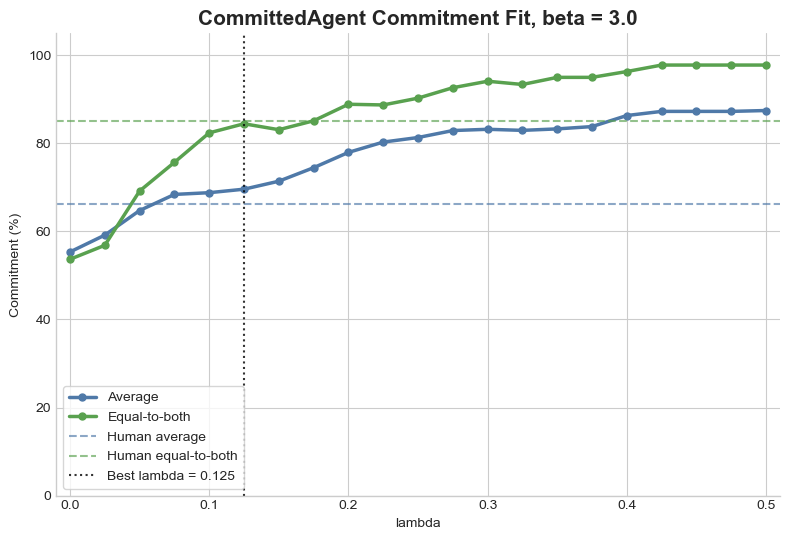

In [3]:
human_avg = (54 + 80 + 54) / (96 + 94 + 94)
human_equal = 80 / 94

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(
    fit_df['lambda'],
    fit_df['sim_human_weighted_average'] * 100,
    marker='o',
    linewidth=2.5,
    markersize=5,
    color='#4f79a8',
    label='Average',
)
ax.plot(
    fit_df['lambda'],
    fit_df['sim_equal_to_both'] * 100,
    marker='o',
    linewidth=2.5,
    markersize=5,
    color='#59a14f',
    label='Equal-to-both',
)
ax.axhline(human_avg * 100, color='#4f79a8', linestyle='--', alpha=0.65, label='Human average')
ax.axhline(human_equal * 100, color='#59a14f', linestyle='--', alpha=0.65, label='Human equal-to-both')
best_lambda = fit_df.loc[fit_df['binomial_nll'].idxmin(), 'lambda']
ax.axvline(best_lambda, color='black', linestyle=':', alpha=0.8, label=f'Best lambda = {best_lambda:g}')
ax.set_title('CommittedAgent Commitment Fit, beta = 3.0', fontsize=15, fontweight='bold')
ax.set_xlabel('lambda')
ax.set_ylabel('Commitment (%)')
ax.set_xlim(-0.01, 0.51)
ax.set_ylim(0, 105)
ax.set_xticks([i / 10 for i in range(6)])
ax.legend(frameon=True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(TWO_LINE_PNG, dpi=200, bbox_inches='tight')
plt.show()

## 2. Four Measures Across Lambda

This section uses the same two hues as above:

- `Average`: across all 2P3G new-goal conditions.
- `Equal-to-both`: only `distanceCondition == "equal_to_both"`.

In [4]:
four_df = pd.read_csv(FOUR_MEASURE_CSV)
four_df.round(3)

,lambda,average_success_percent,equal_success_percent,average_efficiency_percent,average_efficiency_ci_low,average_efficiency_ci_high,equal_efficiency_percent,equal_efficiency_ci_low,equal_efficiency_ci_high,average_commitment_percent,equal_commitment_percent,average_signaling_percent,average_signaling_ci_low,average_signaling_ci_high,equal_signaling_percent,equal_signaling_ci_low,equal_signaling_ci_high
0,0.000,93.056,98.889,88.912,87.404,90.421,98.970,98.434,99.506,55.485,53.676,32.897,28.773,37.020,46.944,38.143,55.746
1,0.025,92.222,98.889,89.217,87.745,90.690,98.290,97.384,99.197,59.336,56.849,32.156,28.101,36.212,43.611,34.721,52.501
2,0.050,92.500,98.889,89.521,88.367,90.674,98.312,97.433,99.191,64.644,69.178,30.913,27.097,34.729,41.667,32.763,50.571
3,0.075,92.222,98.889,89.644,88.399,90.889,98.208,97.282,99.133,68.201,75.694,29.405,25.635,33.175,40.556,32.072,49.039
4,0.100,92.500,98.889,89.572,88.264,90.880,98.142,97.269,99.015,68.277,82.394,30.790,26.683,34.898,41.111,33.099,49.123
5,0.125,92.500,98.889,89.970,88.642,91.297,98.485,97.718,99.252,69.247,84.459,30.956,27.015,34.896,42.500,34.836,50.164
6,0.150,92.222,98.889,90.023,88.741,91.306,98.439,97.580,99.298,71.130,83.108,29.792,26.005,33.579,41.944,33.783,50.106
7,0.175,91.667,97.778,89.576,88.308,90.843,98.167,97.135,99.200,74.167,85.135,28.548,24.626,32.471,42.938,34.915,50.961
8,0.200,91.667,97.778,89.575,88.401,90.749,98.540,97.707,99.372,77.500,88.889,29.527,25.537,33.517,44.915,36.661,53.170
9,0.225,91.111,97.778,89.314,88.113,90.514,98.692,97.873,99.512,79.916,88.732,30.331,25.912,34.750,46.045,37.275,54.816


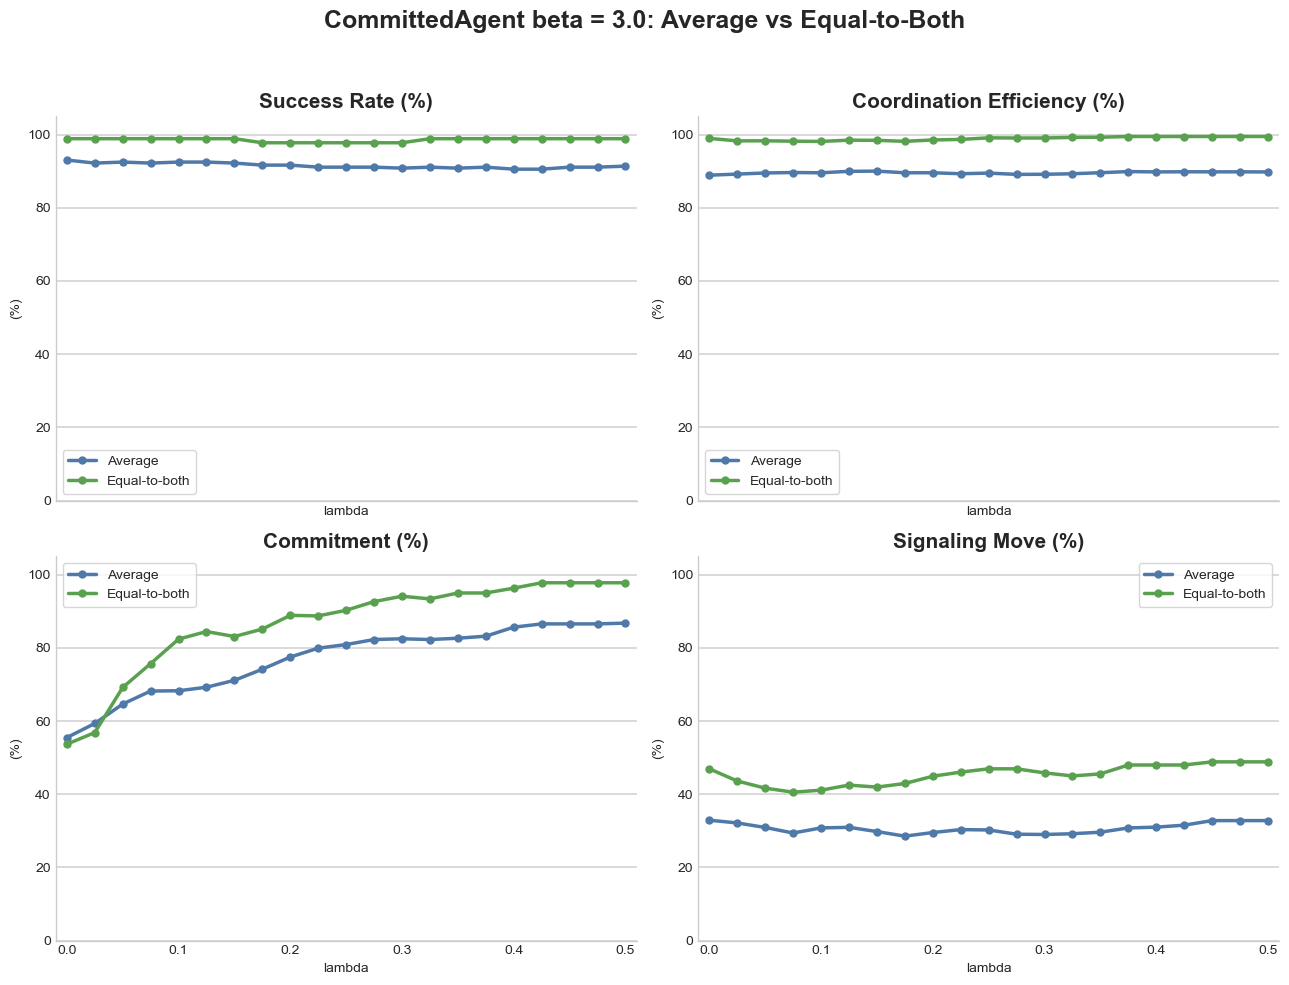

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True)
fig.suptitle('CommittedAgent beta = 3.0: Average vs Equal-to-Both', fontsize=18, fontweight='bold', y=0.98)

panels = [
    ('Success Rate (%)', 'average_success_percent', 'equal_success_percent'),
    ('Coordination Efficiency (%)', 'average_efficiency_percent', 'equal_efficiency_percent'),
    ('Commitment (%)', 'average_commitment_percent', 'equal_commitment_percent'),
    ('Signaling Move (%)', 'average_signaling_percent', 'equal_signaling_percent'),
]

colors = {'Average': '#4f79a8', 'Equal-to-both': '#59a14f'}
for ax, (title, avg_col, eq_col) in zip(axes.ravel(), panels):
    ax.plot(four_df['lambda'], four_df[avg_col], marker='o', linewidth=2.5, markersize=5, color=colors['Average'], label='Average')
    ax.plot(four_df['lambda'], four_df[eq_col], marker='o', linewidth=2.5, markersize=5, color=colors['Equal-to-both'], label='Equal-to-both')
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_xlabel('lambda')
    ax.set_ylabel('(%)')
    ax.set_xlim(-0.01, 0.51)
    ax.set_ylim(0, 105)
    ax.set_xticks([i / 10 for i in range(6)])
    ax.grid(axis='y', color='#cfcfcf', linewidth=1.1)
    ax.grid(axis='x', visible=False)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.legend(frameon=True)

fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FOUR_MEASURE_PNG, dpi=200, bbox_inches='tight')
plt.show()

## 3. Equal-to-Both: CommittedAgent vs Joint-RL vs Human-Human

This comparison focuses only on the `equal_to_both` condition. `CommittedAgent` uses the best trial-level fit from the beta=3 sweep:

```text
beta = 3.0
lambda = 0.125
```

Human-Human is computed from pure human-human unique 2P3G room-trials after deduplicating by `roomId + trialIndex`.

In [6]:
comparison_df = pd.read_csv(COMPARISON_CSV)
comparison_df.round(3)

,group,metric,mean_percent,ci95_percent,n
0,"CommittedAgent\n(beta=3, lambda=0.125)",Success Rate (%),98.889,2.178,90
1,"CommittedAgent\n(beta=3, lambda=0.125)",Coordination Efficiency (%),98.477,0.778,146
2,"CommittedAgent\n(beta=3, lambda=0.125)",Commitment (%),84.459,5.857,148
3,"CommittedAgent\n(beta=3, lambda=0.125)",Signaling Move (%),43.919,8.023,148
4,Joint-RL,Success Rate (%),100.000,0.000,90
5,Joint-RL,Coordination Efficiency (%),97.706,1.031,146
6,Joint-RL,Commitment (%),38.356,7.915,146
7,Joint-RL,Signaling Move (%),45.890,8.111,146
8,Human-Human,Success Rate (%),100.000,0.000,47
9,Human-Human,Coordination Efficiency (%),96.568,2.175,94


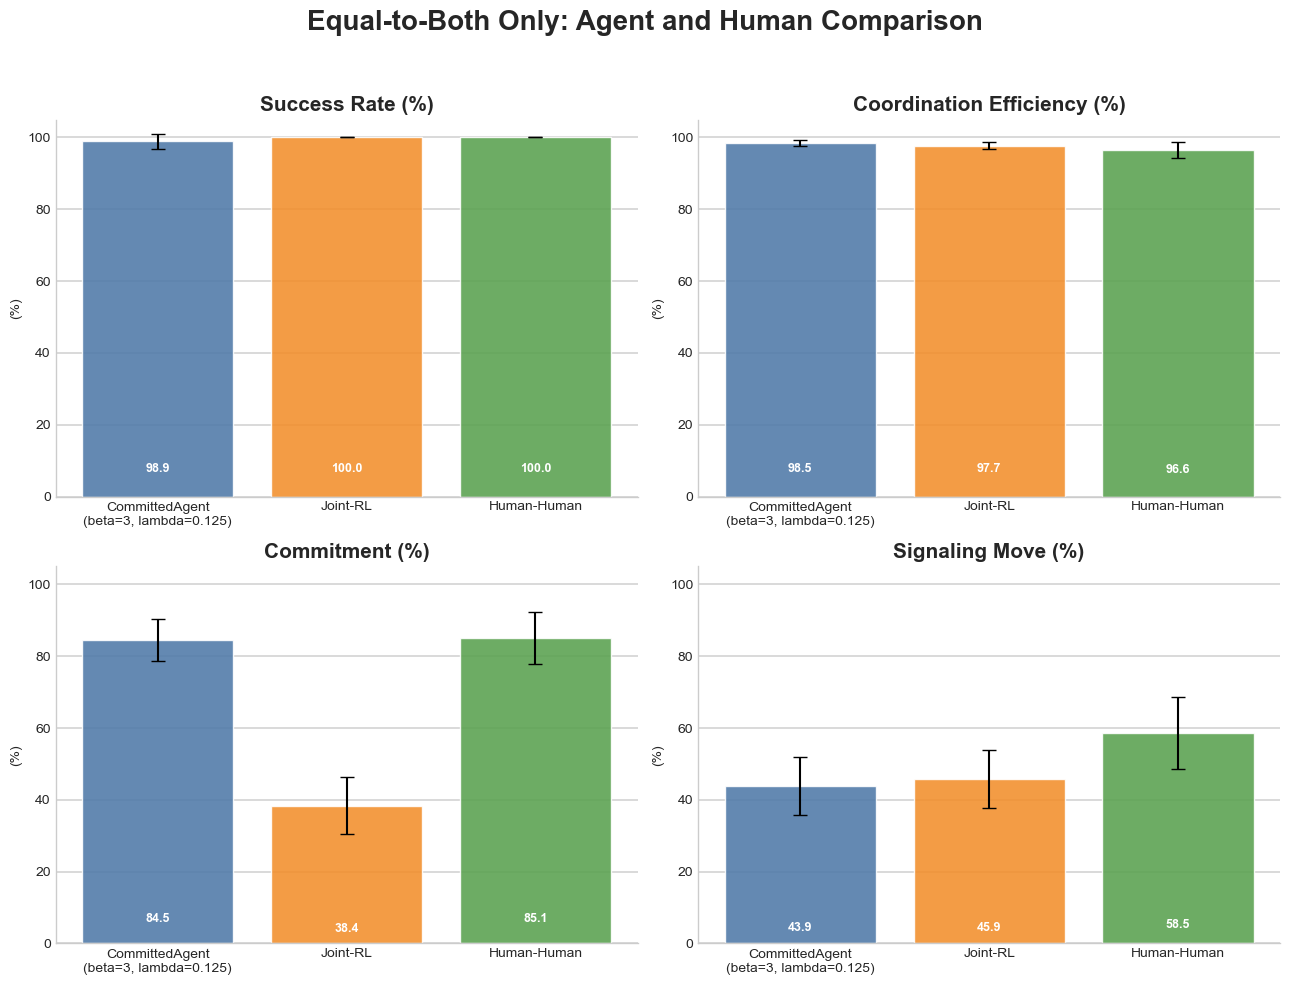

In [7]:
group_order = ['CommittedAgent\n(beta=3, lambda=0.125)', 'Joint-RL', 'Human-Human']
metric_order = ['Success Rate (%)', 'Coordination Efficiency (%)', 'Commitment (%)', 'Signaling Move (%)']
colors = ['#4f79a8', '#f28e2b', '#59a14f']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Equal-to-Both Only: Agent and Human Comparison', fontsize=20, fontweight='bold', y=0.98)

for ax, metric in zip(axes.ravel(), metric_order):
    sub = comparison_df[comparison_df['metric'] == metric].set_index('group').loc[group_order].reset_index()
    x = np.arange(len(group_order))
    bars = ax.bar(
        x,
        sub['mean_percent'],
        yerr=sub['ci95_percent'],
        color=colors,
        alpha=0.88,
        capsize=5,
        edgecolor='white',
        linewidth=1.0,
    )
    ax.set_title(metric, fontsize=15, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.set_ylabel('(%)')
    ax.set_xticks(x)
    ax.set_xticklabels(group_order, fontsize=10)
    ax.grid(axis='y', color='#cfcfcf', linewidth=1.1)
    ax.grid(axis='x', visible=False)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for bar, value in zip(bars, sub['mean_percent']):
        if pd.notna(value):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                max(2, value * 0.06),
                f'{value:.1f}',
                ha='center',
                va='bottom',
                color='white',
                fontsize=9,
                fontweight='bold',
            )

fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(COMPARISON_PNG, dpi=200, bbox_inches='tight')
plt.show()

## 4. All Distance Conditions: CommittedAgent vs Joint-RL vs Human-Human

This section averages across all retained 2P3G distance conditions. Success is computed over all 2P3G trials. Efficiency, commitment, and signaling use post-new-goal eligible observations.

In [8]:
all_distance_df = pd.read_csv(ALL_DISTANCE_CSV)
all_distance_df.round(3)

,group,metric,mean_percent,ci95_percent,n
0,"CommittedAgent\n(beta=3, lambda=0.125)",Success Rate (%),92.500,2.725,360
1,"CommittedAgent\n(beta=3, lambda=0.125)",Coordination Efficiency (%),89.954,1.347,424
2,"CommittedAgent\n(beta=3, lambda=0.125)",Commitment (%),69.247,4.141,478
3,"CommittedAgent\n(beta=3, lambda=0.125)",Signaling Move (%),31.172,4.157,478
4,Joint-RL,Success Rate (%),98.333,1.324,360
5,Joint-RL,Coordination Efficiency (%),88.722,1.359,470
6,Joint-RL,Commitment (%),53.942,4.455,482
7,Joint-RL,Signaling Move (%),35.892,4.287,482
8,Human-Human,Success Rate (%),100.000,0.000,189
9,Human-Human,Coordination Efficiency (%),81.582,3.025,261


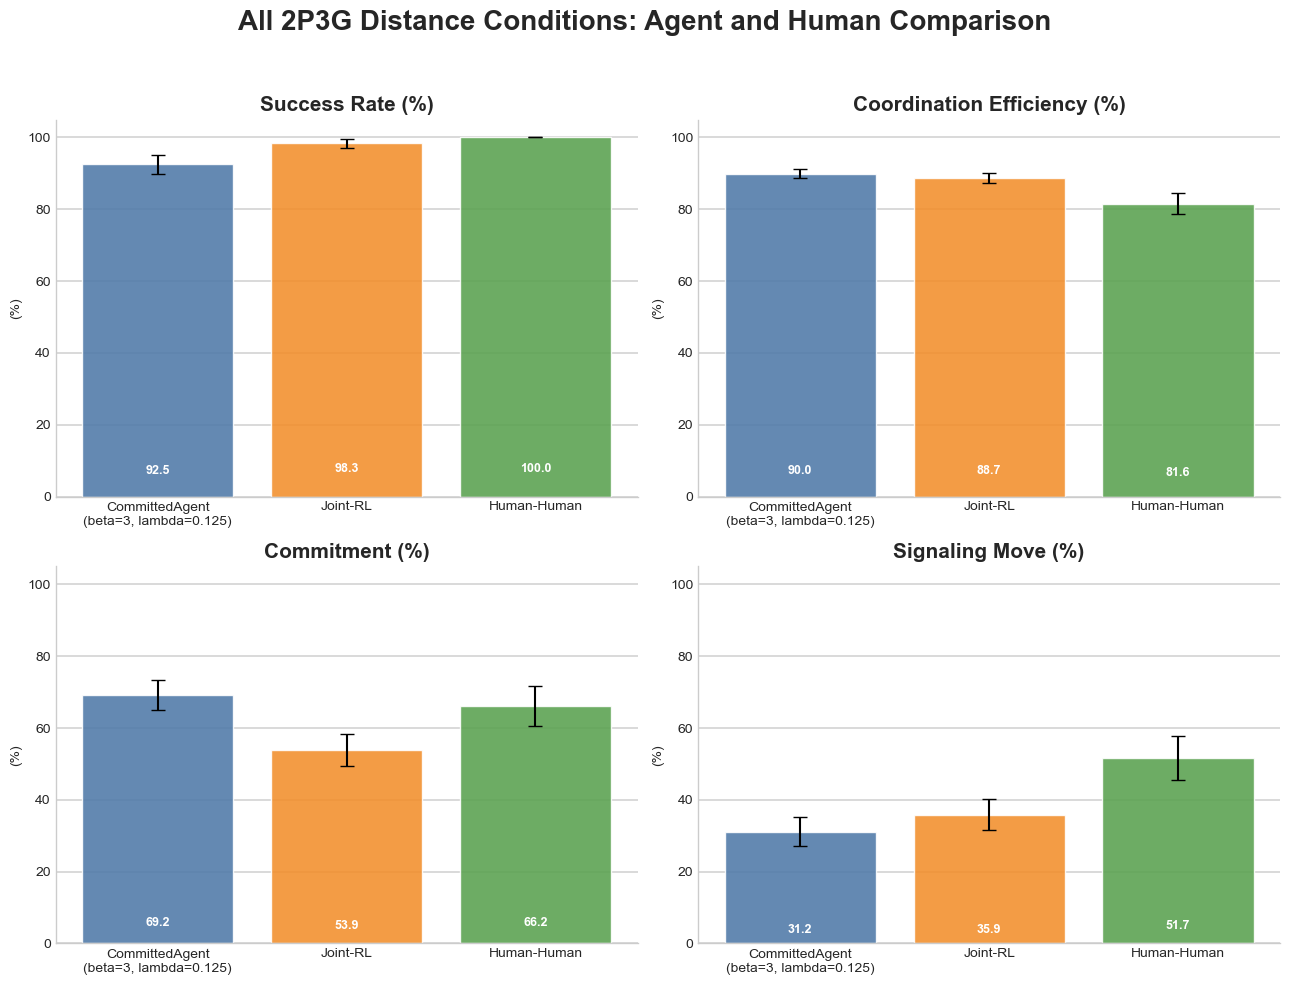

In [9]:
group_order = ['CommittedAgent\n(beta=3, lambda=0.125)', 'Joint-RL', 'Human-Human']
metric_order = ['Success Rate (%)', 'Coordination Efficiency (%)', 'Commitment (%)', 'Signaling Move (%)']
colors = ['#4f79a8', '#f28e2b', '#59a14f']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('All 2P3G Distance Conditions: Agent and Human Comparison', fontsize=20, fontweight='bold', y=0.98)

for ax, metric in zip(axes.ravel(), metric_order):
    sub = all_distance_df[all_distance_df['metric'] == metric].set_index('group').loc[group_order].reset_index()
    x = np.arange(len(group_order))
    bars = ax.bar(
        x,
        sub['mean_percent'],
        yerr=sub['ci95_percent'],
        color=colors,
        alpha=0.88,
        capsize=5,
        edgecolor='white',
        linewidth=1.0,
    )
    ax.set_title(metric, fontsize=15, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.set_ylabel('(%)')
    ax.set_xticks(x)
    ax.set_xticklabels(group_order, fontsize=10)
    ax.grid(axis='y', color='#cfcfcf', linewidth=1.1)
    ax.grid(axis='x', visible=False)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for bar, value in zip(bars, sub['mean_percent']):
        if pd.notna(value):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                max(2, value * 0.06),
                f'{value:.1f}',
                ha='center',
                va='bottom',
                color='white',
                fontsize=9,
                fontweight='bold',
            )

fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(ALL_DISTANCE_PNG, dpi=200, bbox_inches='tight')
plt.show()

## Key Takeaways

- The best trial-level commitment fit remains `lambda = 0.125` when `beta = 3.0`.
- In the `equal_to_both` condition, fitted `CommittedAgent` closely matches Human-Human commitment.
- Joint-RL remains highly successful and efficient, but its equal-to-both commitment is much lower because it does not preserve the old shared goal as an inferred commitment target.
- Human-Human signaling is higher than both agent baselines in the equal-to-both condition.
- Across all distance conditions, fitted `CommittedAgent` matches Human-Human commitment more closely than Joint-RL, while Human-Human has higher signaling.